# Bayesian Optimal Experimental Design — Burgers Equation Tutorial

This notebook demonstrates our BOED proposal on the 1D viscous Burgers equation.
The pipeline covers:
1. **Setup** — PDE model, noise, and discretisation
2. **Prior** — GP prior split into parameter of interest $\theta$ and nuisance $\eta$
3. **Forward model** — $G:(\theta,\eta)\mapsto u(\cdot,T)$
4. **Finite-difference Jacobians** — $J_\theta$, $J_\eta$, and their Monte-Carlo expectations
5. **Covariance matrices** — $\Sigma_Y$, $\Sigma_{\rm noise}$, $\Sigma_{\rm signal}$, $\Sigma_{Y|\theta}$
6. **EIG estimators** — upper bound (BS) and direct estimator (BI)
7. **Greedy sensor placement** comparison

## 1. Imports

In [21]:
import numpy as np
import numpy.linalg as la
import scipy.linalg as sla
import matplotlib.pyplot as plt

from boed.priors.kernels import Matern32, Matern12
from boed.priors.gp_priors import GaussianProcessPrior
from boed.core.noise import NoiseModel, ColoredNoise
from boed.core import make_u0
from boed.pde.burgers import Burgers_CN
from boed.utils.observation import build_selection_matrices

## 2. Setup

We define the spatial grid, PDE model, true initial condition, and observation noise.

In [22]:
np.random.seed(42)

N        = 100      # number of interior grid points
dt       = 0.001
n_steps  = 100
sigma    = 0.05     # noise standard deviation
lambda_  = 1.0
n_samples = 20000

x_grid = np.linspace(0, 1, N + 2)[1:-1]

model   = Burgers_CN(N=N, dt=dt, diffusivity=0.02, lambda_=lambda_)
u0_true = make_u0(x_grid, "gaussian", center=0.25, width=0.07, amplitude=1.5)
noise   = ColoredNoise(sigma_noise=sigma, correlation_length=20.3)

## 3. Prior

The joint parameter $\theta \in \mathbb{R}^{d}$ follows a Gaussian prior:

$$
\theta \sim \mathcal{N}\!\left(m_{\theta},\;
\Sigma_{\theta} \right)
$$


In [23]:
kernel = Matern32(length_scale=0.2, sigma=1.0)
prior  = GaussianProcessPrior(kernel, mu=np.zeros(N), nx=N)

In [24]:
def plot_matrices(matrices, titles, figsize=None, cmap="viridis"):
    """Display a row of matrices side by side with individual colour-bars.

    Parameters
    ----------
    matrices : list of ndarray
        Square matrices to display.
    titles : list of str
        LaTeX-compatible title for each matrix.
    figsize : tuple, optional
        Figure size; defaults to (5 * n, 4).
    cmap : str, optional
        Matplotlib colour-map name.
    """
    n = len(matrices)
    if figsize is None:
        figsize = (5 * n, 4)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]
    for ax, mat, title in zip(axes, matrices, titles):
        im = ax.imshow(mat, cmap=cmap)
        ax.set_title(title)
        fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()



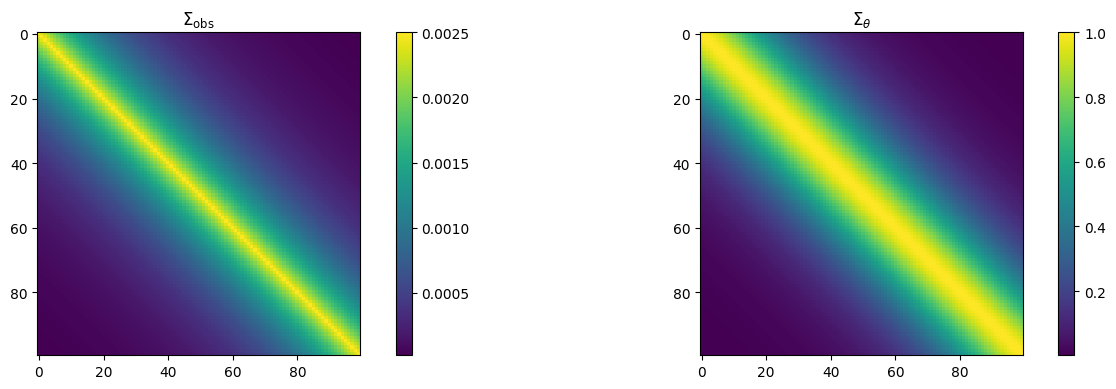

In [25]:

plot_matrices(
    [noise.get_covariance(N), prior.Sigma],
    [r"$\Sigma_{\rm obs}$", r"$\Sigma_\theta$"],
    figsize=(14, 4),
)

## 4. Forward Model

The forward operator $G:(\theta)\mapsto u(\cdot,T)\in\mathbb{R}^N$ runs the
Burgers PDE from the concatenated initial condition $\theta$.

In [26]:
def make_forward_model(pde_model, n_steps):
    """Return the forward operator G(theta, eta) -> u(·, T).

    Parameters
    ----------
    pde_model : object
        PDE solver with an ``evolve(u0, n_steps)`` method.
    n_steps : int
        Number of time steps to run.

    Returns
    -------
    G : callable
        Function ``G(theta) -> ndarray`` of shape ``(N,)``.
    """
    def G(theta: np.ndarray):
        return pde_model.evolve(u0=theta, n_steps=n_steps)[-1, :]
    return G



In [27]:

theta = u0_true.copy()
print(f"theta size : {theta.size}")

G = make_forward_model(pde_model=model, n_steps=n_steps)

# Sanity check: both calling conventions must produce the same output
u1 = G(theta=theta)
print(f"Consistency check ||G(theta,eta) - G(u0)|| = {np.linalg.norm(u1):.2e}")

theta size : 100
Consistency check ||G(theta,eta) - G(u0)|| = 4.53e+00


## 5. Finite-Difference Jacobian

$$
J_\theta(\theta) \in \mathbb{R}^{N\times d},\qquad
J_\theta \approx \frac{G(\theta+h e_j)-G(\theta-h e_j)}{2h}
$$

Cost: $2d$ forward evaluations per sample.

In [28]:
def jacobian_fd(G, theta, h=None):
    """Central finite-difference Jacobian of G with respect to theta.

    Parameters
    ----------
    G     : callable  R^d x R^q -> R^m
    theta : ndarray, shape (d,)
    h     : float, optional
        Step size.  Defaults to ``eps^{1/3} * (||theta|| + 1e-8)``.

    Returns
    -------
    J_theta : ndarray, shape (m, d)
    """
    d = theta.shape[0]
    if h is None:
        h = np.finfo(float).eps ** (1 / 3) * (la.norm(theta) + 1e-8)

    m = G(theta).shape[0]
    J = np.zeros((m, d))
    for j in range(d):
        e_j = np.zeros(d)
        e_j[j] = 1.0
        J[:, j] = (G(theta + h * e_j) - G(theta - h * e_j)) / (2 * h)
    return J

## 6. Covariance Matrices

### 6a. Marginal output covariance $\Sigma_Y$

$$
\Sigma_Y = \Sigma_{\rm obs} + \mathrm{Cov}_{\pi_0}[G(\theta,\eta)]
$$

In [29]:
def estimate_Sigma_Y(G, prior, Sigma_obs, n_samples, rng=None):
    """Estimate Sigma_Y = Sigma_obs + Cov_{pi_0}[G(theta, eta)] by Monte Carlo.

    Samples from the joint prior.

    Parameters
    ----------
    G           : callable
    joint_prior : dict with keys 'mu', 'Sigma', 'd', 'q'
    Sigma_obs   : ndarray (m, m)
    n_samples   : int
    rng         : np.random.Generator or None

    Returns
    -------
    Sigma_Y : ndarray (m, m)
    """
    if rng is None:
        rng = np.random.default_rng()

    theta_samples = rng.multivariate_normal(mean=prior.mu, cov=prior.Sigma, size=n_samples)
    U = np.array([G(theta_samples[k]) for k in range(n_samples)])
    SY = Sigma_obs + np.cov(U, rowvar=False, bias=False)
    return 0.5 * (SY + SY.T)  # symmetrise


In [30]:
Sigma_Y = estimate_Sigma_Y(
    G=G, prior=prior,
    Sigma_obs=noise.get_covariance(N), n_samples=n_samples,
)


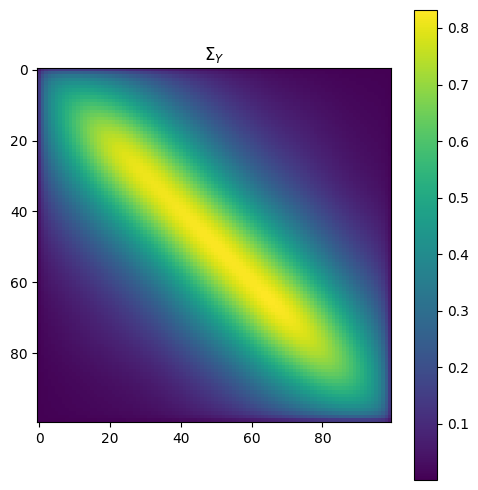

In [31]:

plot_matrices([Sigma_Y], [r"$\Sigma_Y$"], figsize=(5, 5))

### 6b. Noise covariance $\Sigma_{\rm noise}$

$$
\Sigma_{\mathrm{noise}}^{-1} \succeq \mathbb{E}\!\left[\mathcal{I}_{Y\mid\theta}\right]
$$
### Standard setting : $y = u(\theta) + \epsilon$
$$\mathbb{E}\!\left[\mathcal{I}_{Y\mid\theta}\right] = \Sigma_{\rm obs}^{-1}$$

### 6c. Signal covariance $\Sigma_{\rm signal}$

$$
\Sigma_{\mathrm{signal}}^{-1} \succeq \mathcal{I}_Y
$$

We have equality in the linear gaussian case


### Standard setting : $\mathcal{I}_Y = \Sigma_{\rm obs}^{-1} - \Sigma_{\rm obs}^{-1} \mathbb{E}\left[Cov\left(u(\theta)|Y\right)\right] \Sigma_{\rm obs}^{-1}$

In [ ]:
import numpy as np


def solve_linear_matrix_regression_minimization(
    G,
    prior,
    Sigma_obs,
    n_samples=10000,
    random_state=0,
):
    """
    Solve the affine matrix-valued regression problem

        min_{A,b} E[(X - A Y - b)(X - A Y - b)^T],

    where
        theta ~ N(m_theta, Sigma_theta),
        X = u(theta),
        Y = X + eps,
        eps ~ N(0, Sigma_obs), independent.

    Returns
    -------
    A_star : ndarray, shape (p, p)
        Optimal linear matrix.
    b_star : ndarray, shape (p,)
        Optimal intercept.
    M_emp : ndarray, shape (p, p)
        Empirical residual matrix:
            E[(X - A*Y - b*)(X - A*Y - b*)^T]
    M_formula : ndarray, shape (p, p)
        Same quantity computed from covariance formula:
            Sigma_X - Sigma_X (Sigma_X + Sigma_obs)^(-1) Sigma_X
    stats : dict
        Extra moments and samples.
    """
    rng = np.random.default_rng(random_state)

    m_theta = np.asarray(prior.mu)
    Sigma_theta = np.asarray(prior.Sigma)
    Sigma_obs = np.asarray(Sigma_obs)

    d = m_theta.shape[0]
    theta = rng.multivariate_normal(m_theta, Sigma_theta, size=n_samples)

    X = np.asarray([G(th) for th in theta])
    if X.ndim != 2:
        raise ValueError("u(theta) must return a 1D array with fixed length p.")

    n, p = X.shape
    if Sigma_obs.shape != (p, p):
        raise ValueError(f"Sigma_obs must have shape ({p}, {p}).")

    eps = rng.multivariate_normal(np.zeros(p), Sigma_obs, size=n_samples)
    Y = X + eps

    m_X = X.mean(axis=0)
    m_Y = Y.mean(axis=0)

    Xc = X - m_X
    Yc = Y - m_Y

    # Empirical covariances
    Sigma_XY = (Xc.T @ Yc) / n
    Sigma_YY = (Yc.T @ Yc) / n
    Sigma_X = (Xc.T @ Xc) / n

    # Optimal affine predictor X ≈ A Y + b
    A_star = Sigma_XY @ np.linalg.inv(Sigma_YY)
    b_star = m_X - A_star @ m_Y

    # Residual matrix at optimum
    R = X - (Y @ A_star.T + b_star)
    M_emp = (R.T @ R) / n

    # Closed-form matrix for this minimization problem
    M_formula = Sigma_X - Sigma_X @ np.linalg.inv(Sigma_X + Sigma_obs) @ Sigma_X

    stats = {
        "m_X": m_X,
        "m_Y": m_Y,
        "Sigma_X": Sigma_X,
        "Sigma_XY": Sigma_XY,
        "Sigma_YY": Sigma_YY,
        "X": X,
        "Y": Y,
        "residuals": R,
    }

    return A_star, b_star, M_emp, M_formula, stats

In [33]:
A_star, b_star, M_emp, M_formula, stats = solve_linear_matrix_regression_minimization(
    G = G,
    prior = prior,
    Sigma_obs = noise.get_covariance(N),
    n_samples=20000,
    random_state=0,
)
print(M_emp.shape)

(100, 100)


In [34]:
Sigma_obs = noise.get_covariance(N)
Sobs_inv = np.linalg.inv(Sigma_obs)
Iy = Sobs_inv @ (np.eye(N) - M_formula @ Sobs_inv)
Sigma_signal = np.linalg.inv(Iy)

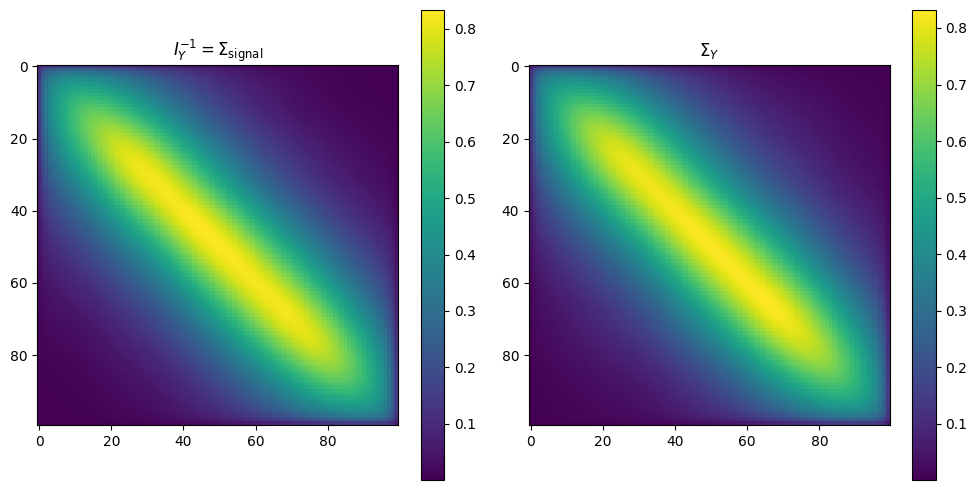

In [42]:
plot_matrices([Sigma_signal, Sigma_Y], [r"$I_Y^{-1} = \Sigma_{\rm signal}$",r"$\Sigma_Y$"], figsize=(10, 5))


In [36]:
print(f"relative error nuc in %: {np.round(np.linalg.norm(Sigma_signal-Sigma_Y,ord='nuc')*100/np.linalg.norm(Sigma_Y,ord='nuc'),2)} %")
print(f"relative error fro in %: {np.round(np.linalg.norm(Sigma_signal-Sigma_Y,ord='fro')*100/np.linalg.norm(Sigma_Y,ord='fro'),2)} %")

relative error nuc in %: 2.15 %
relative error fro in %: 1.83 %


### 6d. Conditional output covariance $\Sigma_{Y|\theta}$

$$
\Sigma_{Y|\theta} = \Sigma_{\rm obs}
$$

## 7. EIG Estimators

For a sensor-selection matrix $W \in \mathbb{R}^{N\times s}$, we define the
**relative** EIG gain (over the full-observation design $I_N$):

$$
\Delta\mathrm{EIG}(W) = \mathrm{EIG}(W) - \mathrm{EIG}(I_N)
= \frac{1}{2}\log\frac{\det(W^\top A\, W)}{\det(W^\top B\, W)}
  - \frac{1}{2}\log\frac{\det(A)}{\det(B)}
$$

where $(A,B)$ is $(\Sigma_{\rm signal}, \Sigma_{\rm obs})$ for the **upper bound (BS)**
and $(\Sigma_Y, \Sigma_{\rm obs})$ for the **direct estimator (BI)**.

### 9a. Upper bound (BS) — based on $\Sigma_{\rm signal}$ and $\Sigma_{\rm Y|\theta}$

In [37]:
def eig_BS(Sigma_signal, Sigma_Y_given_theta, W):
    """EIG upper bound (BS) relative to the full-observation design.

    Parameters
    ----------
    Sigma_signal : ndarray (m, m)
    Sigma_noise  : ndarray (m, m)
    W            : ndarray (m, s)  — sensor selection matrix

    Returns
    -------
    float  — Delta EIG_BS(W)
    """
    def log_ratio(A, B, M):
        _, la_ = la.slogdet(M.T @ A @ M)
        _, lb_ = la.slogdet(M.T @ B @ M)
        return la_ - lb_

    eye = np.eye(Sigma_Y_given_theta.shape[0])
    return 0.5 * (log_ratio(Sigma_signal, Sigma_Y_given_theta, W)
                  - log_ratio(Sigma_signal, Sigma_Y_given_theta, eye))

### 9b. Direct estimator (BI) — based on $\Sigma_Y$ and $\Sigma_{\rm noise}$

In [38]:
def eig_BI(Sigma_Y, Sigma_noise, W):
    """EIG direct estimator (BI) relative to the full-observation design.

    Parameters
    ----------
    Sigma_Y      : ndarray (m, m)
    Sigma_noise  : ndarray (m, m)
    W            : ndarray (m, s)  — sensor selection matrix

    Returns
    -------
    float  — Delta EIG_BI(W)
    """
    def log_ratio(A, B, M):
        _, la_ = la.slogdet(M.T @ A @ M)
        _, lb_ = la.slogdet(M.T @ B @ M)
        return la_ - lb_

    eye = np.eye(Sigma_noise.shape[0])
    return 0.5 * (log_ratio(Sigma_Y, Sigma_noise, W)
                  - log_ratio(Sigma_Y, Sigma_noise, eye))

## 10. Greedy Sensor Placement and Comparison

We greedily maximise the BI lower bound to select a budget of sensors,
then evaluate both estimators on the resulting design.

In [39]:
def greedy_maximize_LB(Sigma_Y, Sigma_noise, n_sensors):
    """Greedy forward selection maximising the BI log-ratio score.

    Parameters
    ----------
    Sigma_Y     : ndarray (N, N)
    Sigma_noise : ndarray (N, N)
    n_sensors   : int

    Returns
    -------
    selected : ndarray of int, shape (n_sensors,)
    """
    N_grid = Sigma_Y.shape[0]
    selected = []
    remaining = list(range(N_grid))

    for _ in range(n_sensors):
        best_idx, best_score = None, -np.inf
        for idx in remaining:
            S  = selected + [idx]
            ix = np.ix_(S, S)
            sign_y, logdet_y = np.linalg.slogdet(Sigma_Y[ix])
            sign_n, logdet_n = np.linalg.slogdet(Sigma_noise[ix])
            if sign_y <= 0 or sign_n <= 0:
                raise ValueError(f"Sub-matrix is not SPD for S={S}")
            score = 0.5 * (logdet_y - logdet_n)
            if score > best_score:
                best_score = score
                best_idx   = idx
        selected.append(best_idx)
        remaining.remove(best_idx)

    return np.array(selected, dtype=int)

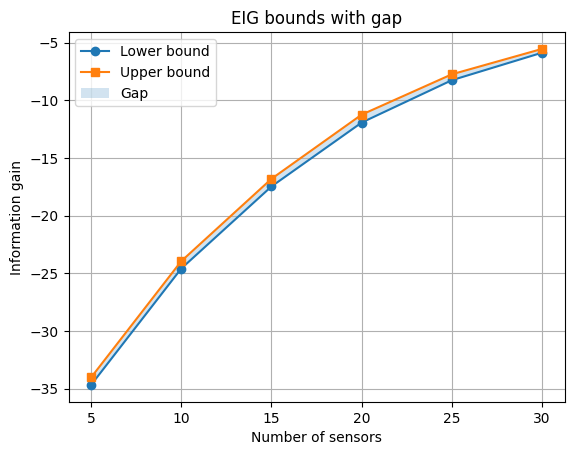

In [40]:
import matplotlib.pyplot as plt

sensor_budgets = [5, 10, 15,20,25,30]
lb_vals = []
ub_vals = []

for budget in sensor_budgets:
    indices = greedy_maximize_LB(
        Sigma_Y=Sigma_Y,
        Sigma_noise=Sigma_obs,
        n_sensors=budget
    )
    W_opt, _ = build_selection_matrices(N, indices)

    lb = eig_BI(Sigma_Y, Sigma_obs, W_opt)
    ub = eig_BS(Sigma_signal, Sigma_obs, W_opt)

    lb_vals.append(lb)
    ub_vals.append(ub)

plt.figure()

# Courbes
plt.plot(sensor_budgets, lb_vals, marker='o', label='Lower bound')
plt.plot(sensor_budgets, ub_vals, marker='s', label='Upper bound')

# Zone entre les deux = gap
plt.fill_between(sensor_budgets, lb_vals, ub_vals, alpha=0.2, label='Gap')

plt.xlabel("Number of sensors")
plt.ylabel("Information gain")
plt.title("EIG bounds with gap")
plt.legend()
plt.grid(True)

plt.show()